# Cross-Model Comparison: BERT vs DistilBERT vs SetFit

This notebook provides a **side-by-side comparison** of three text-classification
models across two benchmark datasets.

| Model | Architecture | Params | Training Paradigm |
|-------|-------------|--------|-------------------|
| **BERT-base-uncased** | 12-layer Transformer encoder | 110 M | Full fine-tuning |
| **DistilBERT-base-uncased** | 6-layer distilled Transformer | 66 M | Full fine-tuning |
| **SetFit (MiniLM-L6-v2)** | 6-layer sentence encoder + logistic head | 22 M | Contrastive + head fitting |

**Datasets**
- **IMDB** — binary sentiment classification (pos / neg), 25 000 training samples
- **AG News** — 4-class topic classification (World / Sports / Business / Sci-Tech), 120 000 training samples

**Data fractions evaluated**: 1 %, 5 %, 10 %, 50 %, 100 % for BERT & DistilBERT; 1 %, 5 %, 10 % for SetFit (few-shot regime only).

> **GPU note ⚡** BERT-IMDB was trained on an **NVIDIA A100** (80 GB HBM2e, 312 TFLOPS FP16).
> All other experiments ran on an **RTX 5080** (~200 TFLOPS FP16, 16 GB GDDR7).
> For fair speed comparison we apply a **×2.0** scaling factor to estimate equivalent
> RTX 5080 training time for the BERT-IMDB run. The actual factor may vary ±20 %
> depending on batch size, mixed-precision settings, and memory-bandwidth utilisation.

In [12]:
import json, os, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# ── Dark theme (consistent with per-model scripts) ──
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#181b24",
    "axes.edgecolor":   "#363c4e",
    "axes.labelcolor":  "#c8cdd8",
    "text.color":       "#e0e4ef",
    "xtick.color":      "#8890a4",
    "ytick.color":      "#8890a4",
    "grid.color":       "#262a36",
    "grid.alpha":       0.6,
    "legend.facecolor": "#1e2230",
    "legend.edgecolor": "#363c4e",
    "legend.fontsize":  9,
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.grid":        True,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "savefig.facecolor":"#0f1117",
    "figure.dpi":       130,
})

C = {
    "blue":   "#6c9bff",   # BERT
    "rose":   "#ff6c8a",   # DistilBERT
    "teal":   "#5eead4",   # SetFit
    "amber":  "#fbbf24",
    "violet": "#a78bfa",
    "muted":  "#8890a4",
}

MODEL_C  = {"BERT": C["blue"], "DistilBERT": C["rose"], "SetFit": C["teal"]}
MODEL_MK = {"BERT": "o",      "DistilBERT": "s",       "SetFit": "D"}

A100_TO_5080 = 2.0   # scaling factor for BERT-IMDB training time

print("Setup complete ✓")

Setup complete ✓


## 1  Load Experiment Data

Each model × dataset combination produced JSON result files.
`main_json` contains accuracy, per-class metrics, per-seed results, and
aggregated efficiency data. `eff_json` (BERT & DistilBERT only) contains
the per-fraction detail including `avg_per_class`.

Adjust `BASE` if you moved the results folder.

In [13]:
BASE = r"C:\Users\yunman\Desktop\SEM2\DSADL\text_models\part3"

# ── Paths ────────────────────────────────────────────────────────────────
FILE_MAP = {
    "bert_imdb": {
        "main": os.path.join(BASE, r"server_output_bert_imdb\results\bert_imdb.json"),
        "eff":  os.path.join(BASE, r"server_output_bert_imdb\results\efficiency_detail_bert\efficiency_detail_bert.json"),
    },
    "bert_agnews": {
        "main": os.path.join(BASE, r"server_output_bert_agnews\results\bert_agnews.json"),
        "eff":  os.path.join(BASE, r"server_output_bert_agnews\results\efficiency_detail_bert\efficiency_detail_bert.json"),
    },
    "distilbert_imdb": {
        "main": os.path.join(BASE, r"server_output_distibert_imdb\results\distilbert_imdb.json"),
        "eff":  os.path.join(BASE, r"server_output_distibert_imdb\results\efficiency_detail\efficiency_detail_distilbert.json"),
    },
    "distilbert_agnews": {
        "main": os.path.join(BASE, r"server_output_distibert_agnews\results\distilbert_agnews.json"),
        "eff":  os.path.join(BASE, r"server_output_distibert_agnews\results\efficiency_detail_distilbert\efficiency_detail_distilbert.json"),
    },
    "setfit_imdb": {
        "main": os.path.join(BASE, r"server_output_setfit_imdb\results\setfit_imdb.json"),
    },
    "setfit_agnews": {
        "main": os.path.join(BASE, r"server_output_setfit_agnews\results\setfit_agnews.json"),
    },
}

# ── Load everything into a dict ──────────────────────────────────────────
D = {}
for key, paths in FILE_MAP.items():
    D[key] = {}
    for tag, p in paths.items():
        with open(p, "r") as f:
            D[key][tag] = json.load(f)
    print(f"  ✓ Loaded {key}")

print(f"\nAll {len(D)} experiment files loaded.")

  ✓ Loaded bert_imdb
  ✓ Loaded bert_agnews
  ✓ Loaded distilbert_imdb
  ✓ Loaded distilbert_agnews
  ✓ Loaded setfit_imdb
  ✓ Loaded setfit_agnews

All 6 experiment files loaded.


## 2  Build Unified Comparison Tables

We extract comparable metrics from the heterogeneous JSON structures into
flat Python dicts keyed by `(dataset, model, fraction)` for easy plotting.

**Key differences in data layout**:
- BERT / DistilBERT: `main["efficiency"]["0.01"]["acc_mean"]`, `main["efficiency"]["0.01"]["train_time_mean"]`, etc.
  Full-data results (100 %) live in `main["full_data"]`. Per-class detail at each fraction lives in a separate `eff_detail` JSON with `avg_per_class`.
- SetFit: flat JSON whose top-level keys are fraction labels. Each entry has
  `acc_mean`, `acc_std`, `train_time_mean`, `infer_time_mean`, `avg_per_class`, `per_seed`.

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# Build unified accuracy / speed / per-class tables
# ═══════════════════════════════════════════════════════════════════════

def _frac_sort_key(k, d):
    "Return numeric fraction for sorting, handling both schemas."
    if "fraction" in d[k]:
        return d[k]["fraction"]
    return float(k)

# ── 2a. Accuracy & Speed at each fraction ────────────────────────────
# Result: acc_table[dataset] = list of {frac, frac_val, BERT, DistilBERT, SetFit}
#         spd_table[dataset] = list of {frac, frac_val, BERT_train, ...}

acc_table = {}
spd_table = {}

for ds_label, ds_tag in [("IMDB", "imdb"), ("AG News", "agnews")]:
    rows_acc = []
    rows_spd = []

    # ── Collect fractions available across all models ──
    # BERT / DistilBERT: efficiency dict keys  +  100 %
    bert_main = D[f"bert_{ds_tag}"]["main"]
    dist_main = D[f"distilbert_{ds_tag}"]["main"]
    sf_data   = D[f"setfit_{ds_tag}"]["main"]

    bert_eff = bert_main["efficiency"]
    dist_eff = dist_main["efficiency"]

    all_frac_vals = set()
    for k in bert_eff:
        all_frac_vals.add(float(k))
    all_frac_vals.add(1.0)  # 100 %

    sf_keys_sorted = sorted(sf_data.keys(), key=lambda k: sf_data[k]["fraction"])
    for k in sf_keys_sorted:
        all_frac_vals.add(sf_data[k]["fraction"])

    for fv in sorted(all_frac_vals):
        fk = str(fv)            # key in efficiency dict
        fl = f"{fv*100:.0f}%"   # display label

        # ── Accuracy ──
        row_a = {"frac": fl, "frac_val": fv}
        # BERT
        if fv < 1.0 and fk in bert_eff:
            row_a["BERT"] = bert_eff[fk]["acc_mean"]
        elif fv == 1.0:
            row_a["BERT"] = bert_main["full_data"]["acc_mean"]
        else:
            row_a["BERT"] = None
        # DistilBERT
        if fv < 1.0 and fk in dist_eff:
            row_a["DistilBERT"] = dist_eff[fk]["acc_mean"]
        elif fv == 1.0:
            row_a["DistilBERT"] = dist_main["full_data"]["acc_mean"]
        else:
            row_a["DistilBERT"] = None
        # SetFit (match by fraction value)
        row_a["SetFit"] = None
        for sk in sf_keys_sorted:
            if abs(sf_data[sk]["fraction"] - fv) < 1e-6:
                row_a["SetFit"] = sf_data[sk]["acc_mean"]
        rows_acc.append(row_a)

        # ── Speed ──
        row_s = {"frac": fl, "frac_val": fv}
        is_bert_imdb = (ds_tag == "imdb")
        # BERT
        if fv < 1.0 and fk in bert_eff:
            raw_t = bert_eff[fk]["train_time_mean"]
            row_s["BERT_train"]    = raw_t * A100_TO_5080 if is_bert_imdb else raw_t
            row_s["BERT_train_orig"] = raw_t
            row_s["BERT_infer"]    = bert_eff[fk]["infer_time_mean"]
        else:
            row_s["BERT_train"] = row_s["BERT_train_orig"] = row_s["BERT_infer"] = None
        # DistilBERT
        if fv < 1.0 and fk in dist_eff:
            row_s["DistilBERT_train"] = dist_eff[fk]["train_time_mean"]
            row_s["DistilBERT_infer"] = dist_eff[fk]["infer_time_mean"]
        else:
            row_s["DistilBERT_train"] = row_s["DistilBERT_infer"] = None
        # SetFit
        row_s["SetFit_train"] = row_s["SetFit_infer"] = None
        for sk in sf_keys_sorted:
            if abs(sf_data[sk]["fraction"] - fv) < 1e-6:
                row_s["SetFit_train"] = sf_data[sk]["train_time_mean"]
                row_s["SetFit_infer"] = sf_data[sk]["infer_time_mean"]
        rows_spd.append(row_s)

    acc_table[ds_label] = rows_acc
    spd_table[ds_label] = rows_spd

# ── 2b. Per-class metrics at each fraction ───────────────────────────
# pcm_table[dataset][model] = {class_name: {metric: [values-by-frac]}}
# frac_labels_pcm[dataset][model] = [labels]

pcm_table  = {}
pcm_fracs  = {}

for ds_label, ds_tag in [("IMDB", "imdb"), ("AG News", "agnews")]:
    pcm_table[ds_label] = {}
    pcm_fracs[ds_label] = {}

    for model_tag, model_label in [("bert", "BERT"), ("distilbert", "DistilBERT")]:
        mkey = f"{model_tag}_{ds_tag}"
        main_d = D[mkey]["main"]
        eff_d  = D[mkey]["eff"]
        per_seed = main_d["full_data_per_seed"]
        class_names = list(per_seed[0]["per_class"].keys())

        detail_keys = sorted(eff_d.keys(), key=lambda k: eff_d[k]["fraction"])
        frac_lbls = [f"{eff_d[k]['fraction']*100:.0f}%" for k in detail_keys]
        frac_lbls.append("100%")

        metrics = ["f1", "precision", "recall"]
        cdata = {}
        for cn in class_names:
            cdata[cn] = {m: [] for m in metrics}

        for dk in detail_keys:
            avg_pc = eff_d[dk].get("avg_per_class", {})
            for cn in class_names:
                for m in metrics:
                    cdata[cn][m].append(avg_pc.get(cn, {}).get(m, None))

        # 100 % from per_seed average
        for cn in class_names:
            for m in metrics:
                vals = [s["per_class"][cn][m] for s in per_seed if cn in s["per_class"]]
                cdata[cn][m].append(np.mean(vals) if vals else None)

        pcm_table[ds_label][model_label] = cdata
        pcm_fracs[ds_label][model_label] = frac_lbls

    # SetFit
    sf = D[f"setfit_{ds_tag}"]["main"]
    sf_sorted = sorted(sf.keys(), key=lambda k: sf[k]["fraction"])
    class_names_sf = list(sf[sf_sorted[0]]["avg_per_class"].keys())
    frac_lbls_sf = [f"{sf[k]['fraction']*100:.0f}%" for k in sf_sorted]

    cdata_sf = {}
    for cn in class_names_sf:
        cdata_sf[cn] = {m: [] for m in ["f1", "precision", "recall"]}
    for sk in sf_sorted:
        for cn in class_names_sf:
            for m in ["f1", "precision", "recall"]:
                cdata_sf[cn][m].append(sf[sk]["avg_per_class"][cn][m])

    pcm_table[ds_label]["SetFit"] = cdata_sf
    pcm_fracs[ds_label]["SetFit"] = frac_lbls_sf

print("Unified tables built ✓")
for ds in acc_table:
    fracs_avail = [r["frac"] for r in acc_table[ds]]
    print(f"  {ds}: fractions = {fracs_avail}")

Unified tables built ✓
  IMDB: fractions = ['1%', '5%', '10%', '25%', '50%', '100%']
  AG News: fractions = ['1%', '5%', '10%', '25%', '50%', '100%']


## 3  Overall Accuracy Comparison

The plot below shows **mean accuracy (3 seeds)** at each training-data fraction.
SetFit is only evaluated in the few-shot regime (1 %–10 %).

**Key observations**:
- BERT consistently achieves the highest accuracy at every fraction, though the
  margin over DistilBERT is small (≈ 0.5–1 pp).
- DistilBERT closely tracks BERT with roughly half the parameters and training
  time, making it an excellent accuracy-to-cost trade-off.
- SetFit (MiniLM-L6) lags behind by ≈ 3–5 pp in the 1 %–10 % range. This is
  because even 1 % of IMDB (250 samples) or AG News (1 200 samples) already
  exceeds SetFit's sweet spot of 8–64 examples per class, where contrastive
  learning shines. At these data volumes full fine-tuning can optimise all
  transformer layers end-to-end, outperforming the frozen-encoder + logistic-head
  approach.

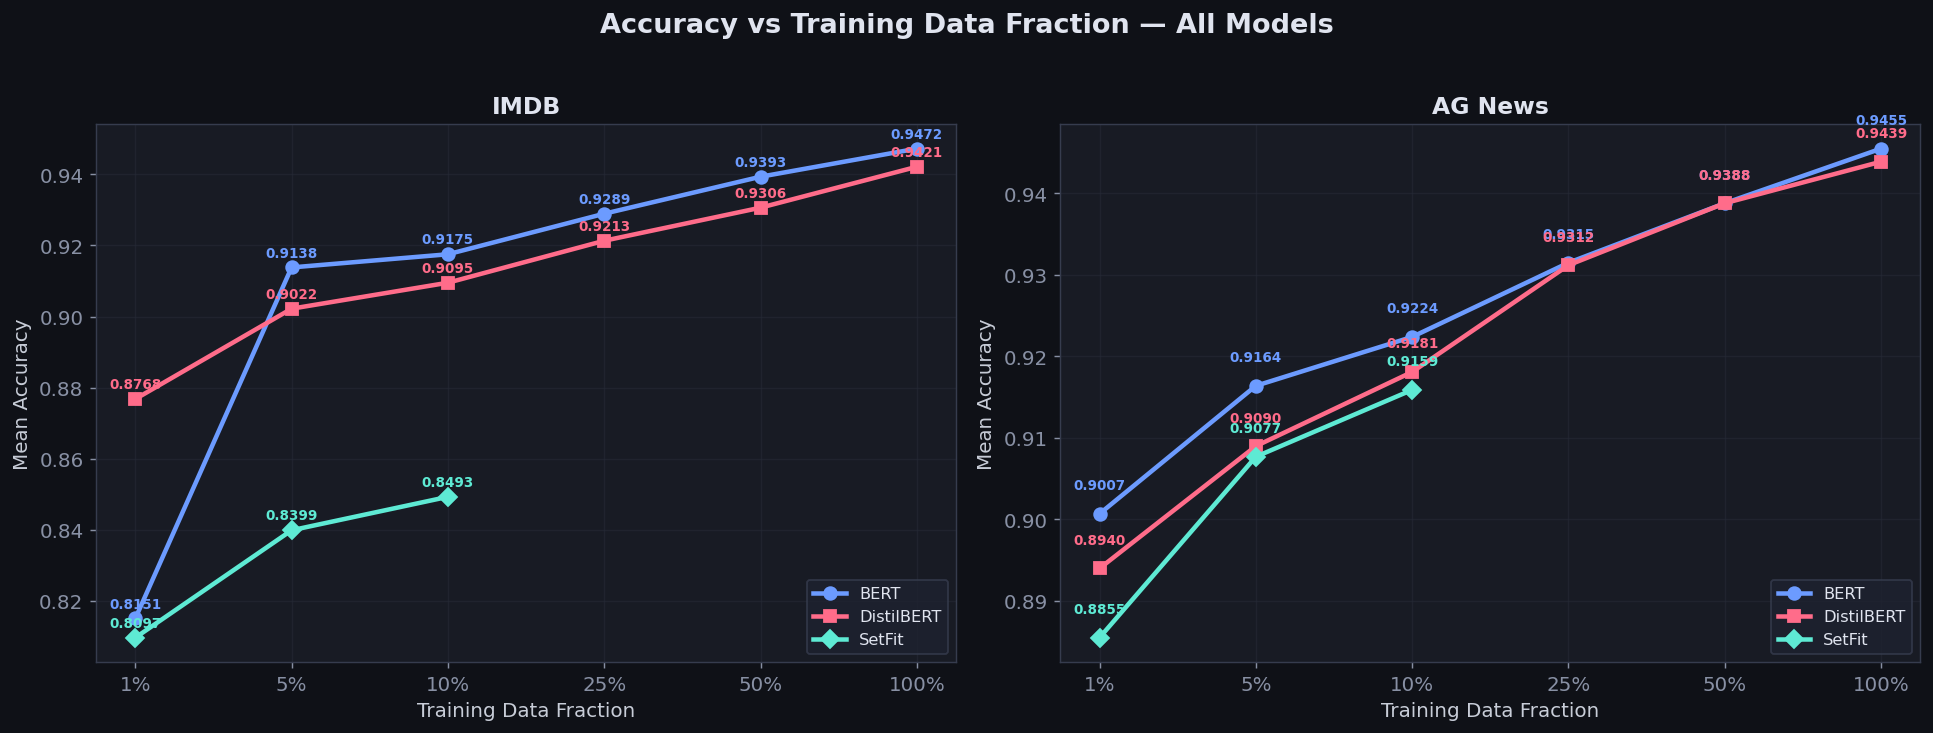

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, ds_label in zip(axes, ["IMDB", "AG News"]):
    rows = acc_table[ds_label]
    frac_labels = [r["frac"] for r in rows]
    x = np.arange(len(rows))

    for model in ["BERT", "DistilBERT", "SetFit"]:
        vals = [r[model] for r in rows]
        # filter None for plotting
        xs = [xi for xi, v in zip(x, vals) if v is not None]
        ys = [v  for v in vals if v is not None]
        ax.plot(xs, ys, "-" + MODEL_MK[model], color=MODEL_C[model],
                lw=2.5, ms=7, label=model, zorder=3)
        for xi, yi in zip(xs, ys):
            ax.text(xi, yi + 0.003, f"{yi:.4f}", ha="center", fontsize=7.5,
                    color=MODEL_C[model], fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(frac_labels)
    ax.set_xlabel("Training Data Fraction")
    ax.set_ylabel("Mean Accuracy")
    ax.set_title(ds_label, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right")

fig.suptitle("Accuracy vs Training Data Fraction — All Models",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 4  Per-Class Classification Performance

For each dataset we show **F1 / Precision / Recall per class** as training data
grows. Each row is one model; each column is one metric. This reveals whether a
model struggles with specific classes at low data volumes.

**Typical findings**:
- On AG News, the *World* and *Sports* classes tend to be easier to separate,
  while *Business* and *Sci-Tech* are more commonly confused at very low data
  fractions.
- On IMDB the two classes (positive / negative) are roughly balanced in
  difficulty; precision and recall stay close to each other.

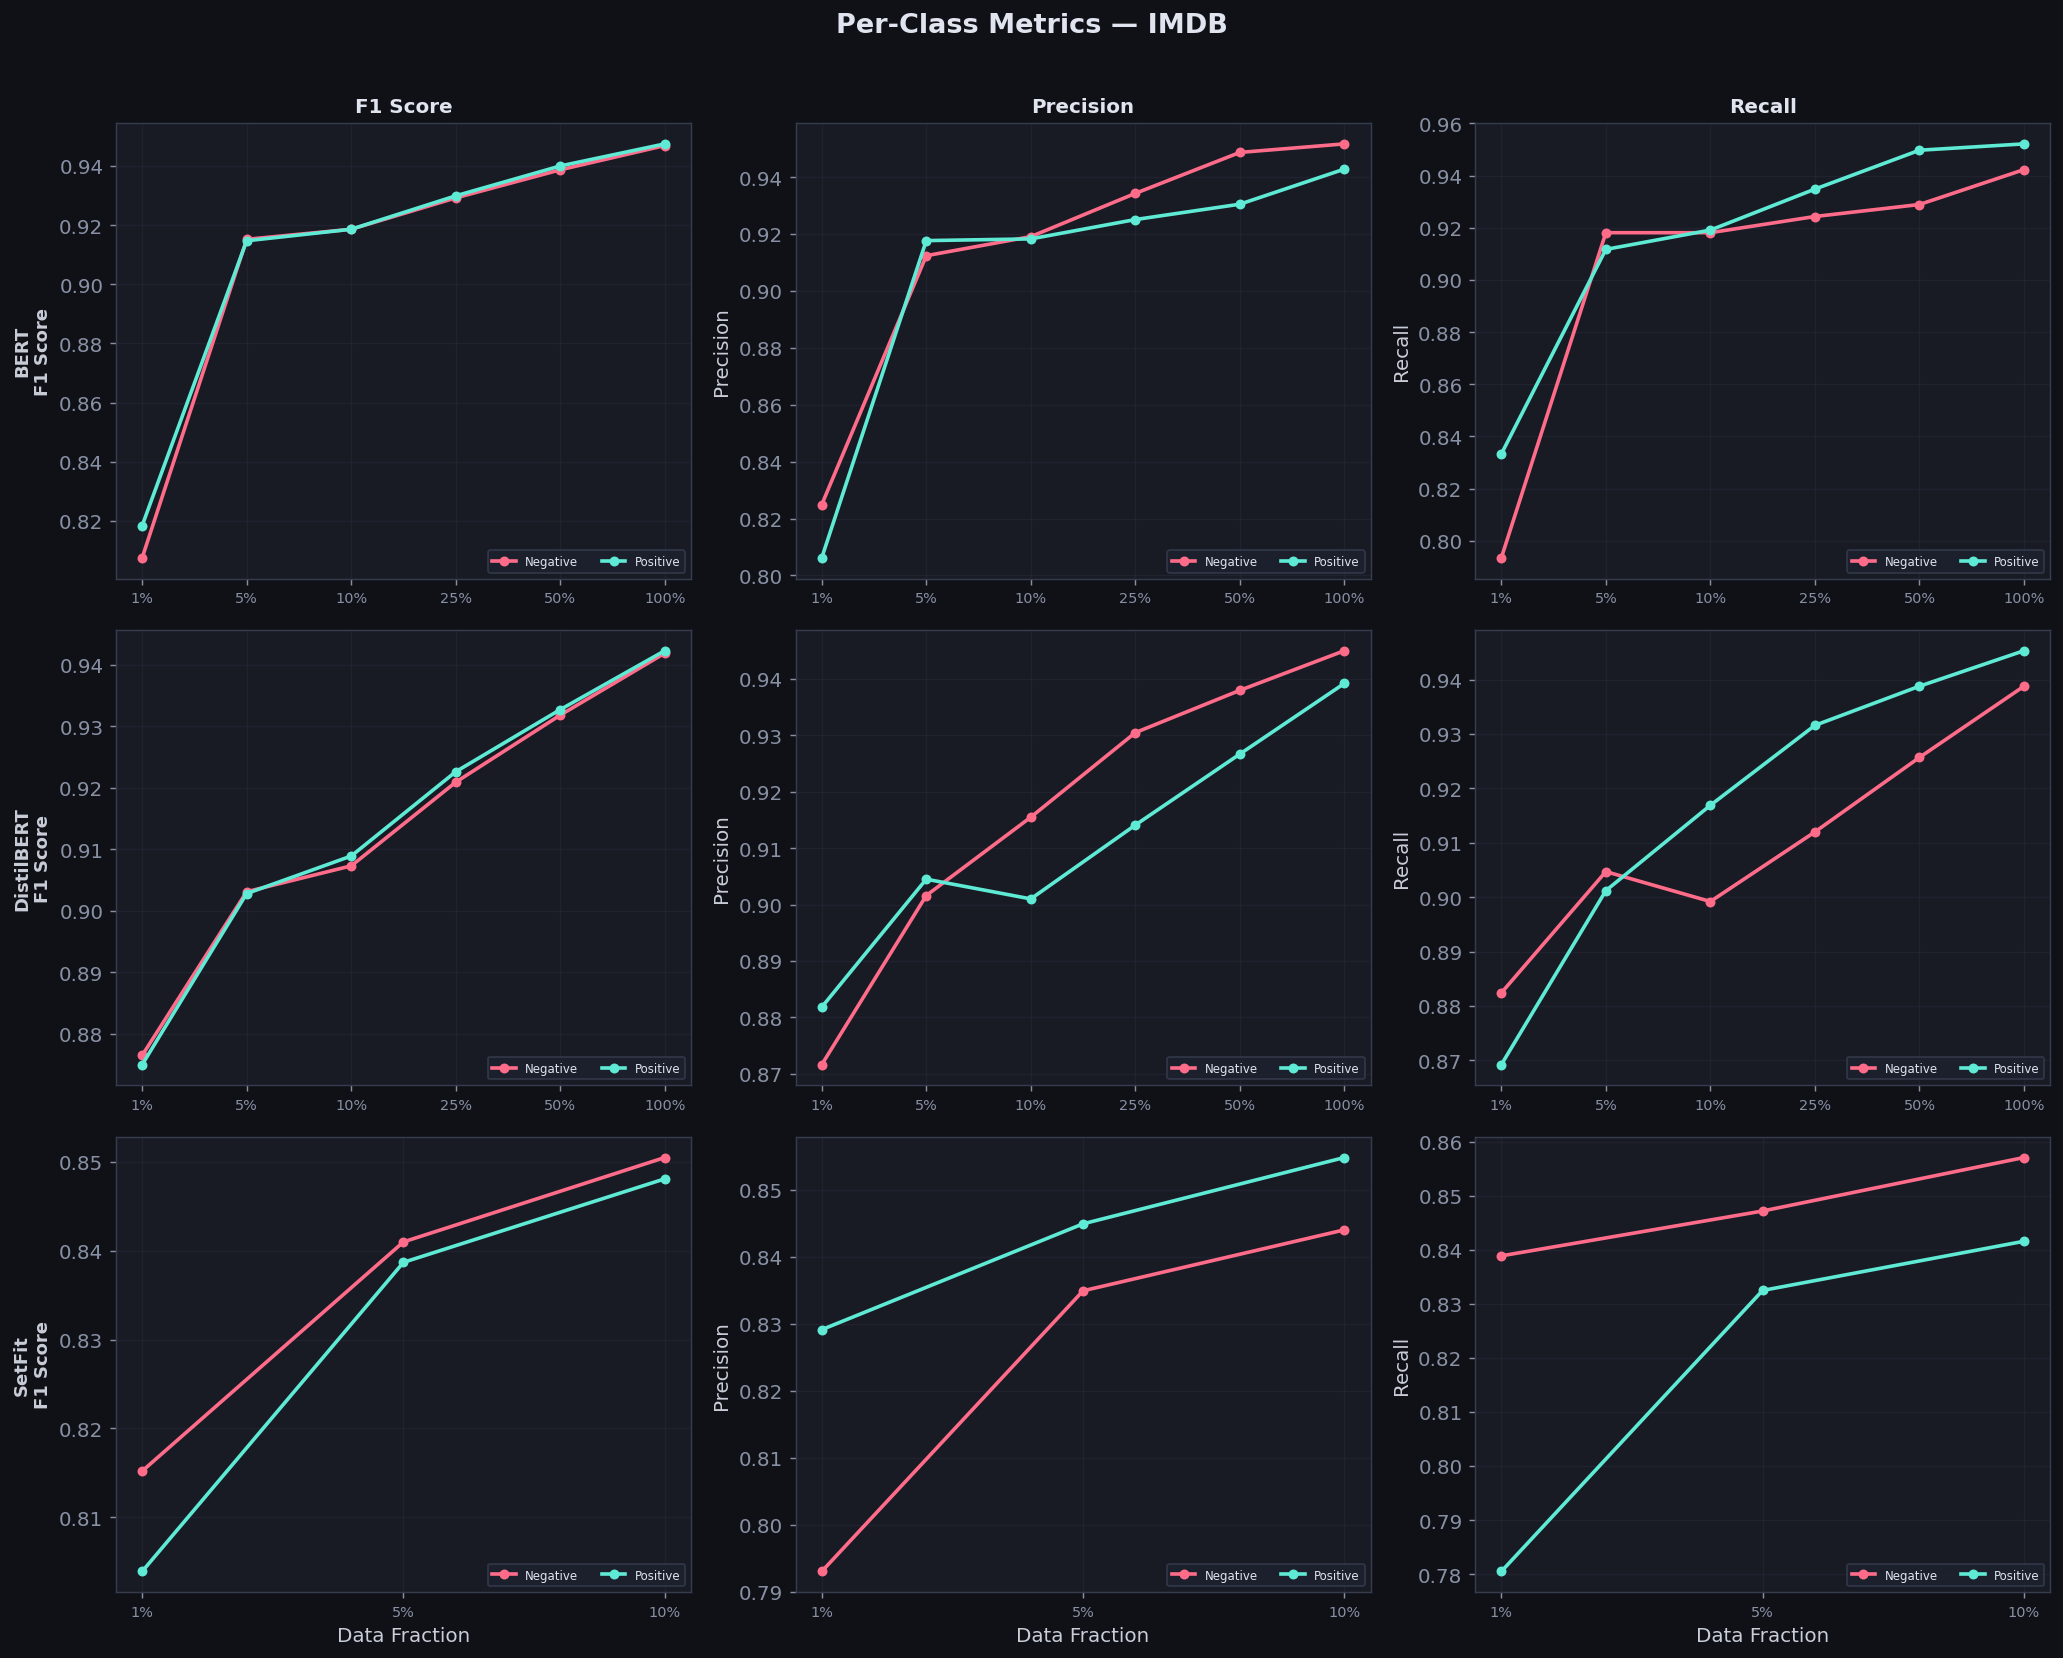

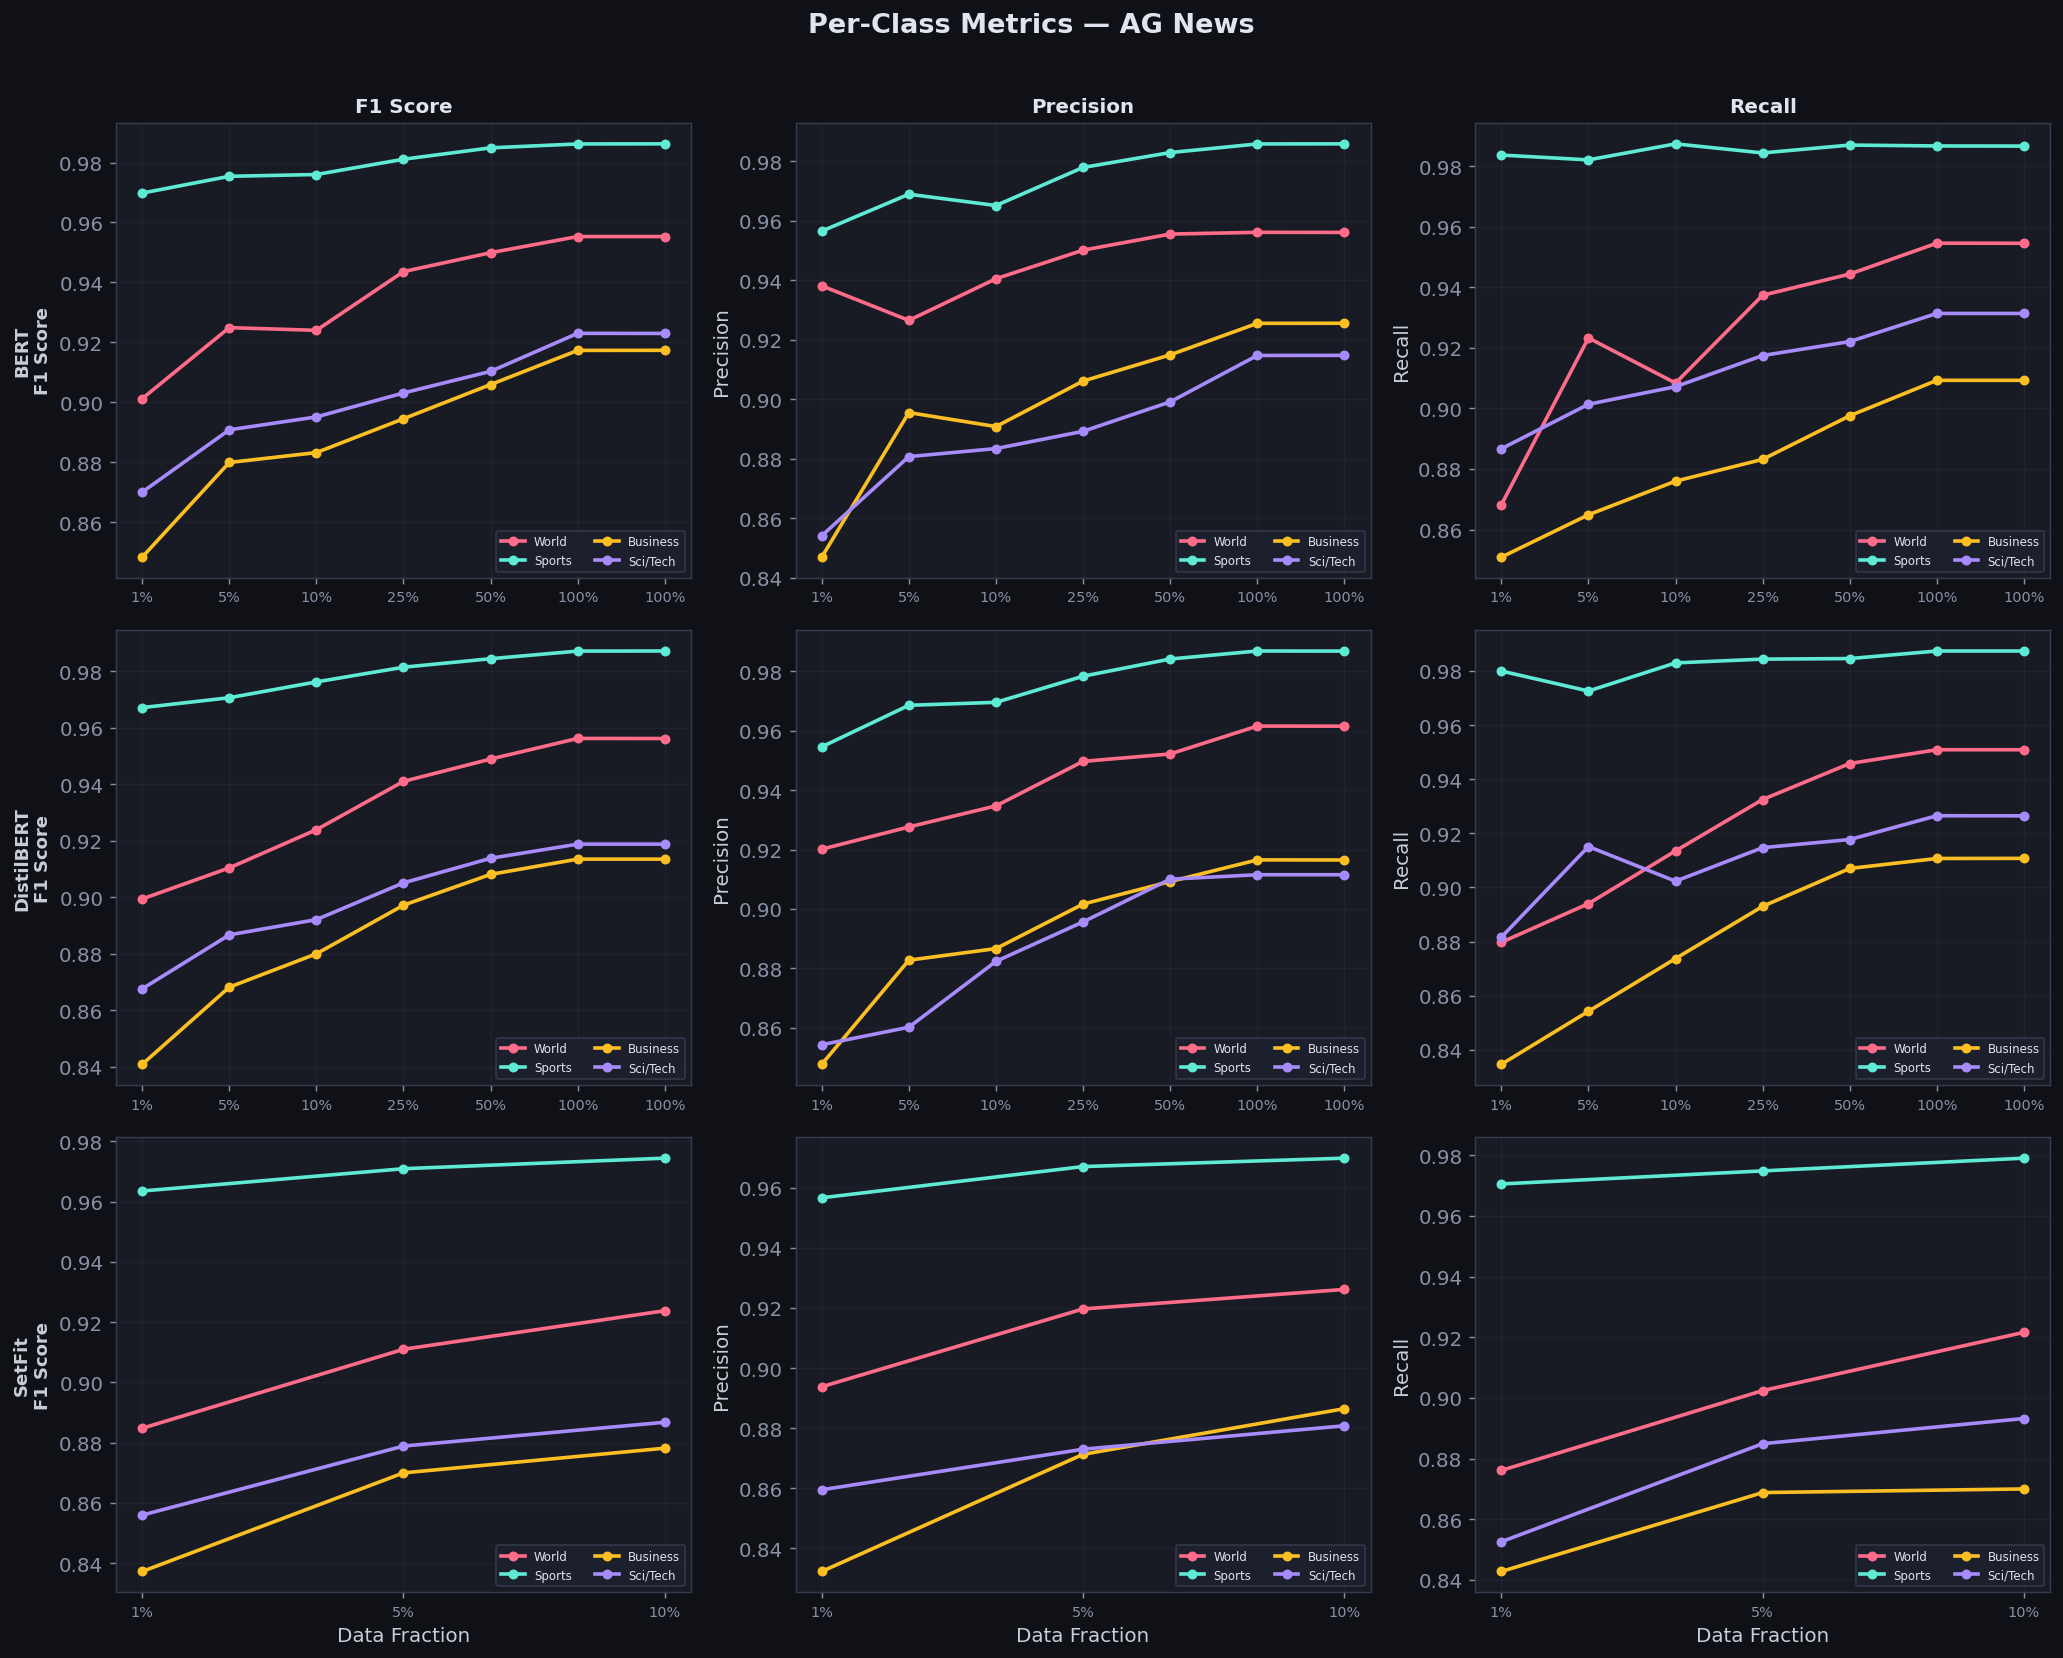

In [16]:
_palette = [C["rose"], C["teal"], C["amber"], C["violet"], C["blue"]]

for ds_label in ["IMDB", "AG News"]:
    models = ["BERT", "DistilBERT", "SetFit"]
    metrics = ["f1", "precision", "recall"]
    titles  = ["F1 Score", "Precision", "Recall"]

    fig, axes = plt.subplots(len(models), len(metrics),
                             figsize=(16, 4.2 * len(models)),
                             sharex="row")

    for row, model in enumerate(models):
        cdata = pcm_table[ds_label][model]
        flabels = pcm_fracs[ds_label][model]
        class_names = list(cdata.keys())
        x = np.arange(len(flabels))

        class_colors = {cn: _palette[i % len(_palette)]
                        for i, cn in enumerate(class_names)}

        for col, (metric, mtitle) in enumerate(zip(metrics, titles)):
            ax = axes[row, col]
            for cn in class_names:
                vals = cdata[cn][metric]
                ax.plot(x, vals, "-o", lw=2, ms=4.5,
                        color=class_colors[cn], label=cn)
            ax.set_xticks(x)
            ax.set_xticklabels(flabels, fontsize=8)
            if row == len(models) - 1:
                ax.set_xlabel("Data Fraction")
            if col == 0:
                ax.set_ylabel(f"{model}\n{mtitle}", fontsize=10, fontweight="bold")
            else:
                ax.set_ylabel(mtitle)
            if row == 0:
                ax.set_title(mtitle, fontsize=11, fontweight="bold")
            ax.legend(fontsize=6.5, loc="lower right", ncol=2)

    fig.suptitle(f"Per-Class Metrics — {ds_label}",
                 fontsize=15, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()

## 5  Training Time Comparison

Grouped bar charts show the **mean training time** (across 3 seeds) at the
fractions where all three models were evaluated (1 %, 5 %, 10 %).

For BERT-IMDB the *estimated RTX 5080 time* is shown (original A100 time × 2.0).
The original A100 time is annotated in parentheses for reference.

**Key observations**:
- DistilBERT trains in roughly **half** the wall-clock time of BERT at every
  fraction — a direct consequence of having 6 layers instead of 12.
- SetFit's training time is between DistilBERT and BERT. Although its model is
  much smaller (22 M params), the contrastive-learning phase generates O(n²)
  sentence pairs, which adds overhead that partially offsets the smaller model size.
- Training time scales roughly linearly with data fraction for all models.

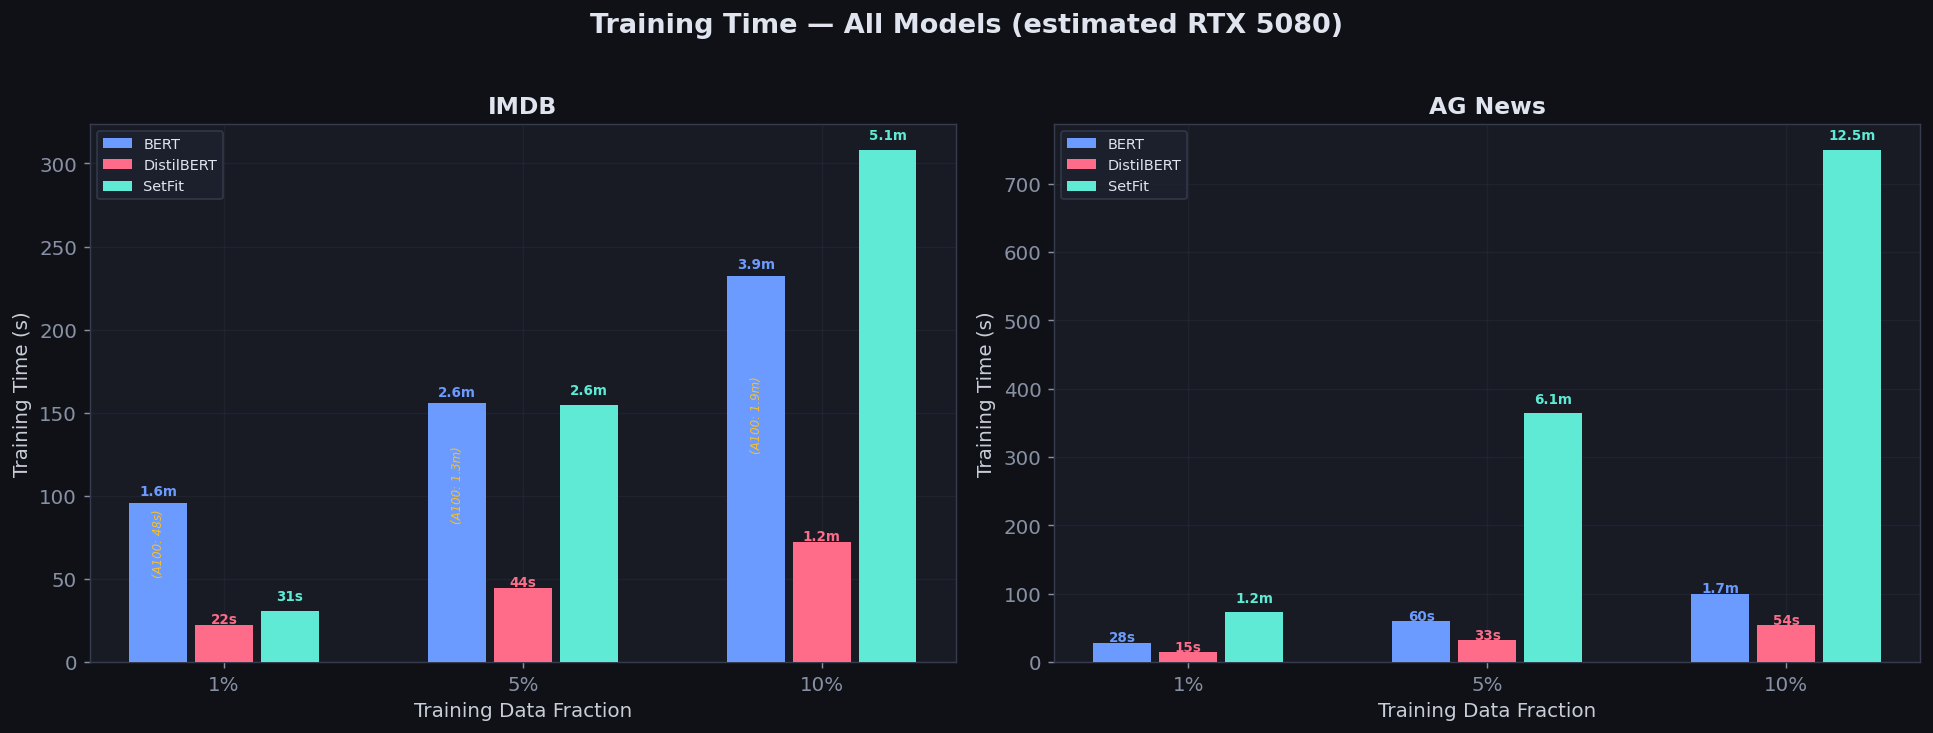

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, ds_label in zip(axes, ["IMDB", "AG News"]):
    rows = [r for r in spd_table[ds_label]
            if r["BERT_train"] is not None
            and r["DistilBERT_train"] is not None
            and r["SetFit_train"] is not None]
    frac_labels = [r["frac"] for r in rows]
    x = np.arange(len(rows))
    w = 0.22

    for i, (model, key_t) in enumerate([
        ("BERT",       "BERT_train"),
        ("DistilBERT", "DistilBERT_train"),
        ("SetFit",     "SetFit_train"),
    ]):
        vals = [r[key_t] for r in rows]
        offset = (i - 1) * w
        bars = ax.bar(x + offset, vals, w * 0.88, label=model,
                      color=MODEL_C[model], edgecolor="none", zorder=3)
        for bar, v in zip(bars, vals):
            label_txt = f"{v:.0f}s"
            if v >= 60:
                label_txt = f"{v/60:.1f}m"
            ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.02,
                    label_txt, ha="center", fontsize=7.5,
                    color=MODEL_C[model], fontweight="bold")

    # Annotate original A100 time for BERT-IMDB
    if ds_label == "IMDB":
        for j, r in enumerate(rows):
            orig = r["BERT_train_orig"]
            if orig is not None:
                label_txt = f"(A100: {orig:.0f}s)"
                if orig >= 60:
                    label_txt = f"(A100: {orig/60:.1f}m)"
                ax.text(j - w, r["BERT_train"] * 0.55, label_txt,
                        ha="center", fontsize=6.5, color=C["amber"],
                        fontstyle="italic", rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(frac_labels)
    ax.set_xlabel("Training Data Fraction")
    ax.set_ylabel("Training Time (s)")
    ax.set_title(ds_label, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Training Time — All Models (estimated RTX 5080)",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6  Inference Time Comparison

Inference time is largely independent of how much training data the model saw
(architecture stays the same). We plot the **raw `infer_time_mean`** values from
each experiment's JSON at each overlapping fraction.

> **⚠ Unit caveat:** BERT / DistilBERT record inference time for the **full test
> set** in one pass, while SetFit may record a **per-sample** or per-batch time.
> If the bars look orders of magnitude apart, check your JSON files for unit
> consistency. The chart below shows whatever value is in `infer_time_mean` as-is,
> so you can verify directly.

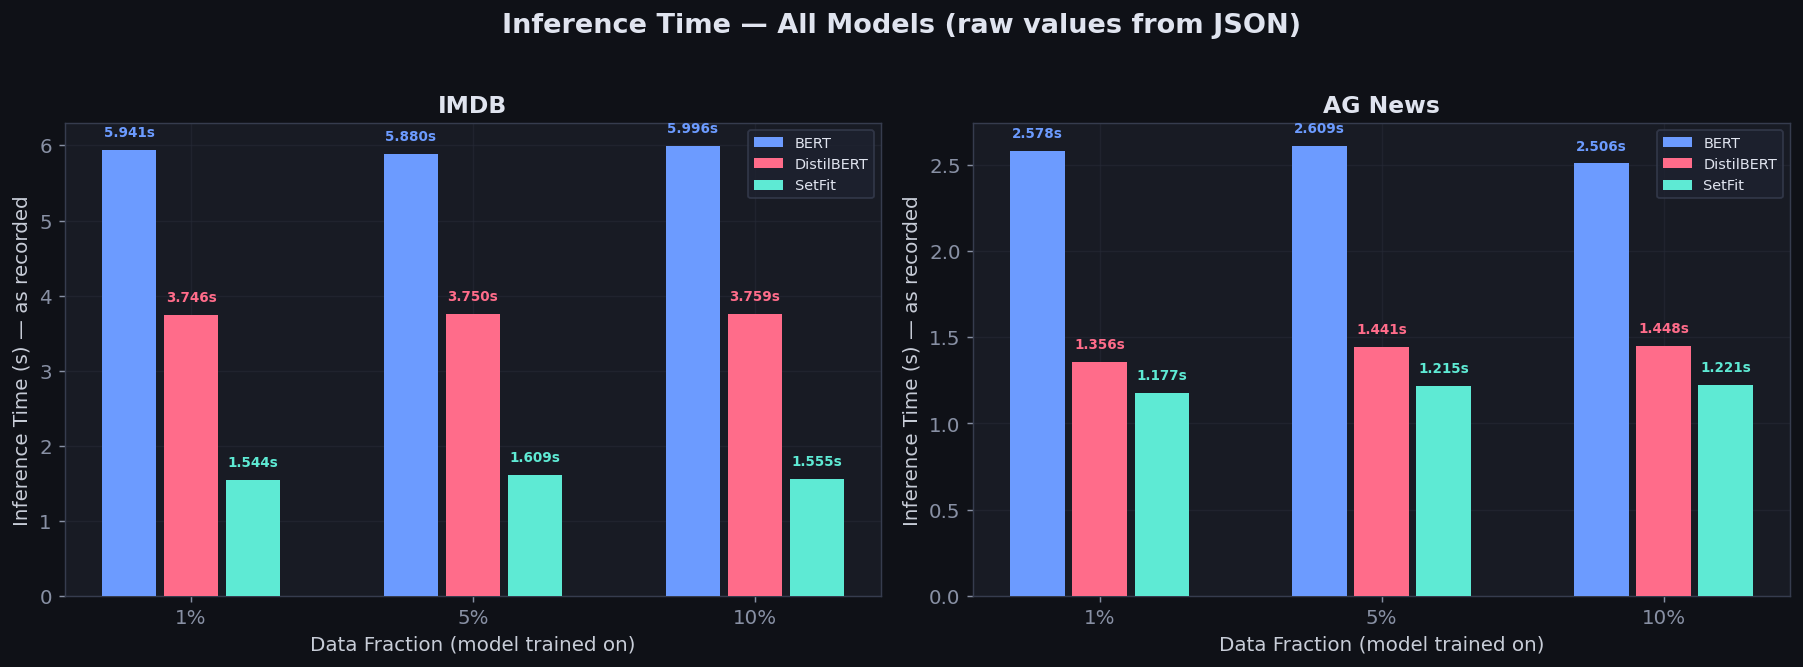

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds_label in zip(axes, ["IMDB", "AG News"]):
    # Take fractions where all three have inference data
    rows = [r for r in spd_table[ds_label]
            if r.get("BERT_infer") is not None
            and r.get("DistilBERT_infer") is not None
            and r.get("SetFit_infer") is not None]
    if not rows:
        ax.text(0.5, 0.5, "No overlapping data", transform=ax.transAxes,
                ha="center", color=C["muted"])
        continue

    frac_labels = [r["frac"] for r in rows]
    x = np.arange(len(rows))
    w = 0.22

    all_vals = []
    for i, (model, key_i) in enumerate([
        ("BERT",       "BERT_infer"),
        ("DistilBERT", "DistilBERT_infer"),
        ("SetFit",     "SetFit_infer"),
    ]):
        vals = [r[key_i] for r in rows]
        all_vals.extend(vals)
        offset = (i - 1) * w
        bars = ax.bar(x + offset, vals, w * 0.88, label=model,
                      color=MODEL_C[model], edgecolor="none", zorder=3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + max(all_vals)*0.03,
                    f"{v:.3f}s", ha="center", fontsize=7.5,
                    color=MODEL_C[model], fontweight="bold")

    # Check if values span > 10x — likely a unit mismatch
    if max(all_vals) / (min(all_vals) + 1e-9) > 10:
        ax.text(0.5, 0.92,
                "⚠ Values differ by >10×  — check unit consistency in JSON",
                transform=ax.transAxes, ha="center", fontsize=8,
                color=C["amber"], fontstyle="italic",
                bbox=dict(boxstyle="round,pad=0.3", fc="#fbbf2418", ec=C["amber"]))

    ax.set_xticks(x)
    ax.set_xticklabels(frac_labels)
    ax.set_xlabel("Data Fraction (model trained on)")
    ax.set_ylabel("Inference Time (s) — as recorded")
    ax.set_title(ds_label, fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Inference Time — All Models (raw values from JSON)",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 7  Summary Table (Few-Shot Regime: 1 %–10 %)

The table below collects accuracy and training time for the three overlapping
fractions where all models were evaluated.

In [19]:
def fmt_time(t):
    "Format seconds into human-readable string."
    if t is None:
        return "—"
    if t >= 3600:
        return f"{t/3600:.1f} h"
    if t >= 60:
        return f"{t/60:.1f} min"
    return f"{t:.0f} s"

for ds_label in ["IMDB", "AG News"]:
    print(f"\n{'═'*82}")
    print(f"  {ds_label}")
    print(f"{'═'*82}")
    header = f"{'Frac':>6}  {'BERT Acc':>10}  {'DistilB Acc':>12}  {'SetFit Acc':>11}  " \
             f"{'BERT Time':>10}  {'DistilB Time':>13}  {'SetFit Time':>12}"
    print(header)
    print("─" * len(header))

    acc_rows = acc_table[ds_label]
    spd_rows = spd_table[ds_label]

    for ar, sr in zip(acc_rows, spd_rows):
        if ar["SetFit"] is None:
            continue  # only show few-shot fracs
        bert_a  = f"{ar['BERT']:.4f}" if ar['BERT'] else "—"
        dist_a  = f"{ar['DistilBERT']:.4f}" if ar['DistilBERT'] else "—"
        sf_a    = f"{ar['SetFit']:.4f}" if ar['SetFit'] else "—"
        bert_t  = fmt_time(sr["BERT_train"])
        dist_t  = fmt_time(sr["DistilBERT_train"])
        sf_t    = fmt_time(sr["SetFit_train"])
        # For IMDB, also show A100 original
        if ds_label == "IMDB" and sr["BERT_train_orig"] is not None:
            bert_t += f" (A100: {fmt_time(sr['BERT_train_orig'])})"
        print(f"{ar['frac']:>6}  {bert_a:>10}  {dist_a:>12}  {sf_a:>11}  "
              f"{bert_t:>10}  {dist_t:>13}  {sf_t:>12}")
    print()


══════════════════════════════════════════════════════════════════════════════════
  IMDB
══════════════════════════════════════════════════════════════════════════════════
  Frac    BERT Acc   DistilB Acc   SetFit Acc   BERT Time   DistilB Time   SetFit Time
──────────────────────────────────────────────────────────────────────────────────────
    1%      0.8151        0.8768       0.8097  1.6 min (A100: 48 s)           22 s          31 s
    5%      0.9138        0.9022       0.8399  2.6 min (A100: 1.3 min)           44 s       2.6 min
   10%      0.9175        0.9095       0.8493  3.9 min (A100: 1.9 min)        1.2 min       5.1 min


══════════════════════════════════════════════════════════════════════════════════
  AG News
══════════════════════════════════════════════════════════════════════════════════
  Frac    BERT Acc   DistilB Acc   SetFit Acc   BERT Time   DistilB Time   SetFit Time
──────────────────────────────────────────────────────────────────────────────────────
   

## 8  Discussion: Why Does SetFit Lag Behind at 1 %–10 %?

SetFit was designed for **extreme few-shot** scenarios (8–64 labelled examples
per class). The 1 % split of IMDB already provides **~125 examples per class**,
and 1 % of AG News gives **~300 per class** — both well above SetFit's intended
operating point. At these data volumes, full fine-tuning dominates for three
main reasons:

1. **End-to-end gradient flow.** BERT and DistilBERT fine-tune *every*
   transformer layer, allowing the model to adapt deep representations to the
   target task. SetFit freezes the encoder after contrastive training and only
   fits a logistic head, which caps representational capacity.

2. **Model capacity.** MiniLM-L6-v2 has 22 M parameters versus BERT's 110 M.
   With sufficient data, the larger model can exploit its extra capacity.

3. **Contrastive pair overhead.** SetFit constructs O(n²) sentence pairs for
   contrastive training, so its training time does not drop as fast as
   expected when data shrinks. Meanwhile full fine-tuning on the same amount
   of data is a single forward-backward pass per sample.

**When would SetFit win?** In a true few-shot setting (≤ 64 examples per class)
where BERT / DistilBERT would severely overfit their classifier head before
learning useful representations, SetFit's contrastive objective provides a much
stronger inductive bias.

### GPU Normalisation Note

BERT-IMDB training times were collected on an A100 GPU. To make them comparable
to the RTX 5080 runs, we multiplied by a factor of **2.0×**. This
estimate is based on the FP16 tensor-core TFLOPS ratio:

| GPU | FP16 Tensor TFLOPS | HBM | Est. Relative Speed |
|-----|-------------------|-----|---------------------|
| A100 (80 GB) | 312 | 80 GB HBM2e | 1.0× |
| RTX 5080     | ~200 | 16 GB GDDR7 | ~0.5× (i.e. 2× slower) |

The actual factor varies with batch size (memory-bound vs compute-bound
regime), mixed-precision configuration, and data-loading pipeline, so
±20 % uncertainty is reasonable.

## 9  At-a-Glance: Model Profiles at 10 % Data

Two separate panels per dataset: **left** shows accuracy (absolute), **right**
shows relative training speed (normalised so fastest model = 1.0).
Keeping them on separate axes avoids the confusion of mixing a 0.85–0.93
accuracy range with a 0–1 normalised speed range.

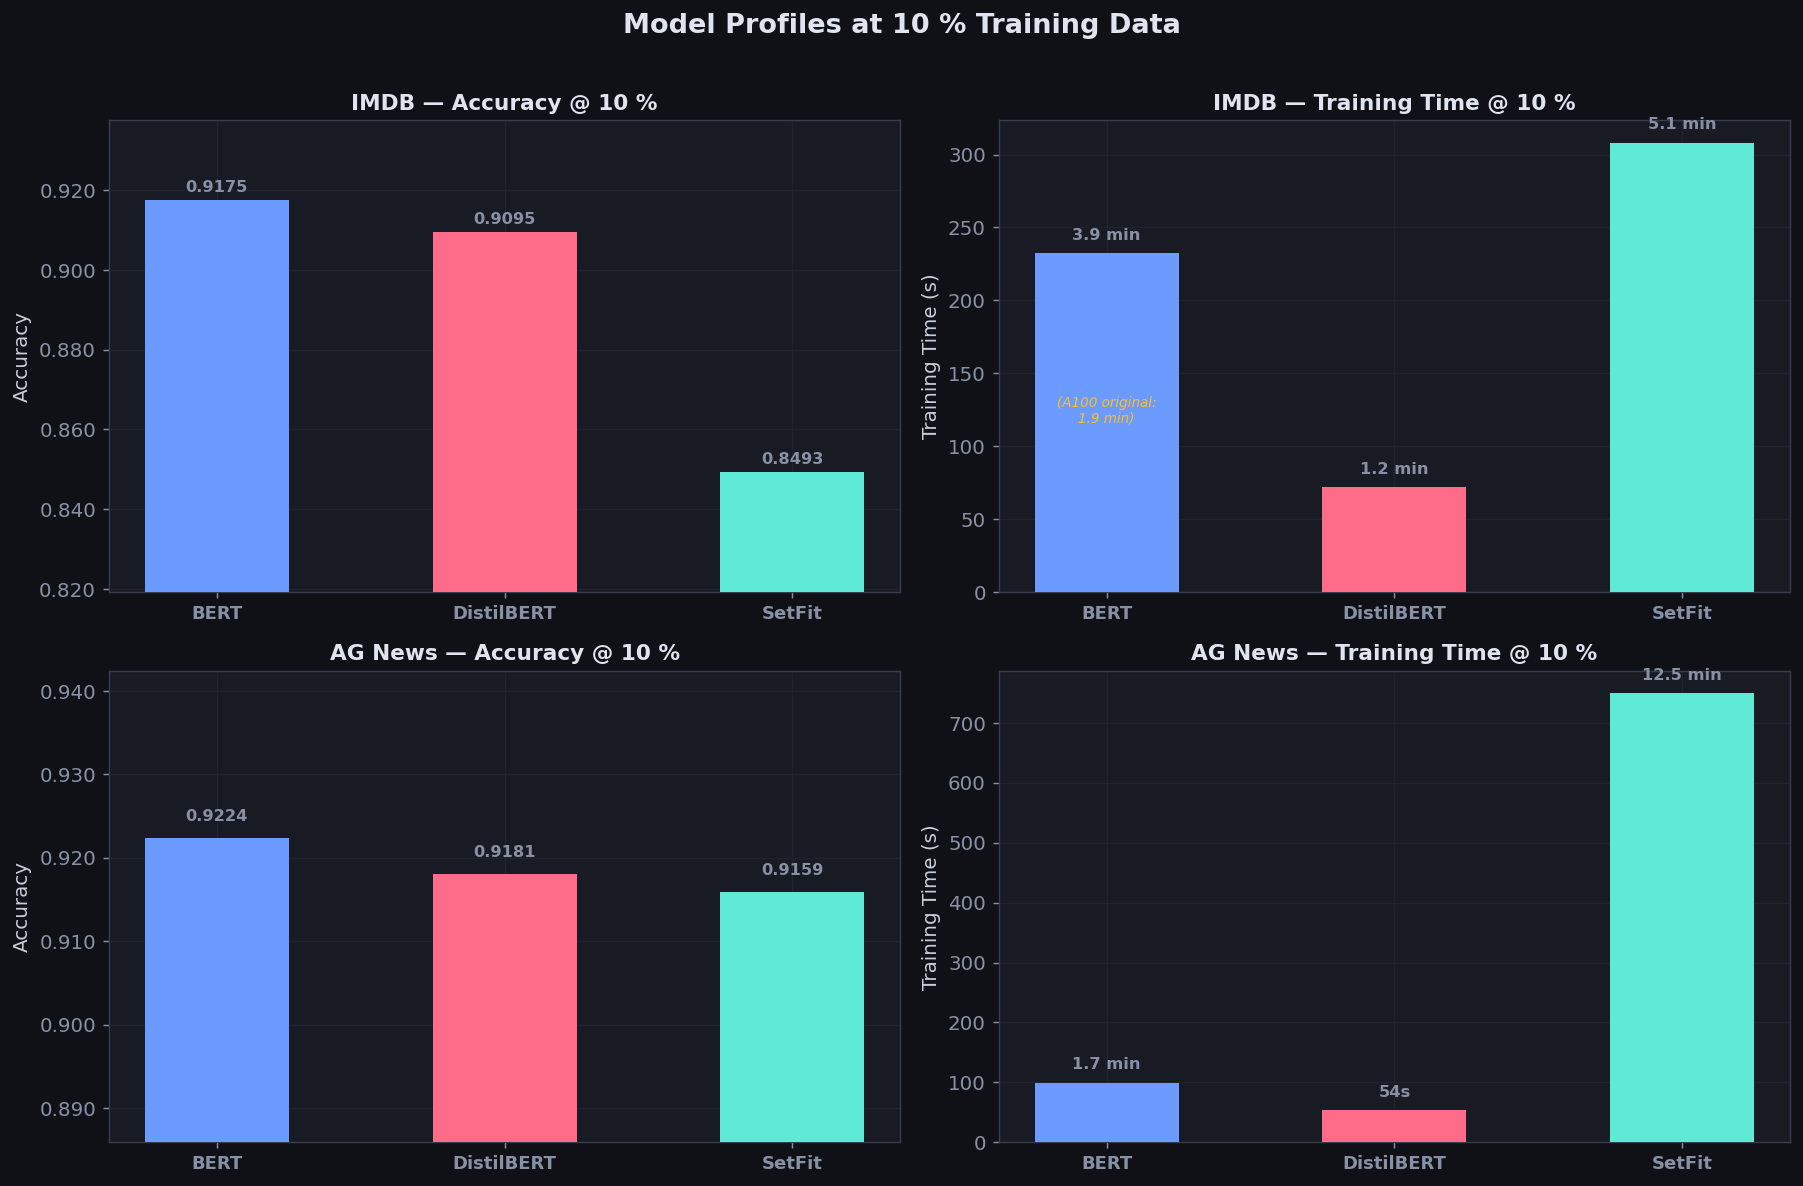

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, ds_label in enumerate(["IMDB", "AG News"]):
    acc_row = [r for r in acc_table[ds_label] if r["frac"] == "10%"][0]
    spd_row = [r for r in spd_table[ds_label] if r["frac"] == "10%"][0]

    models = ["BERT", "DistilBERT", "SetFit"]
    accs = [acc_row[m] for m in models]

    train_ts = [
        spd_row["BERT_train"],
        spd_row["DistilBERT_train"],
        spd_row["SetFit_train"],
    ]

    x = np.arange(len(models))

    # ── Left panel: Accuracy ──
    ax = axes[row, 0]
    bars = ax.bar(x, accs, 0.5, zorder=3, edgecolor="none",
                  color=[MODEL_C[m] for m in models])
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
                f"{v:.4f}", ha="center", fontsize=9,
                color=C["muted"], fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, fontweight="bold")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{ds_label} — Accuracy @ 10 %", fontsize=12, fontweight="bold")
    # tighter y-range around actual values
    ax.set_ylim(min(accs) - 0.03, max(accs) + 0.02)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    # ── Right panel: Training time (raw seconds) ──
    ax = axes[row, 1]
    bars = ax.bar(x, train_ts, 0.5, zorder=3, edgecolor="none",
                  color=[MODEL_C[m] for m in models])
    for bar, v in zip(bars, train_ts):
        lbl = f"{v:.0f}s" if v < 60 else f"{v/60:.1f} min"
        ax.text(bar.get_x() + bar.get_width()/2, v + max(train_ts)*0.03,
                lbl, ha="center", fontsize=9,
                color=C["muted"], fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, fontweight="bold")
    ax.set_ylabel("Training Time (s)")
    ax.set_title(f"{ds_label} — Training Time @ 10 %", fontsize=12, fontweight="bold")

    # Annotate A100 original for BERT-IMDB
    if ds_label == "IMDB":
        orig = spd_row["BERT_train_orig"]
        if orig is not None:
            lbl_orig = f"{orig:.0f}s" if orig < 60 else f"{orig/60:.1f} min"
            ax.text(0, train_ts[0] * 0.5,
                    f"(A100 original:\n{lbl_orig})",
                    ha="center", fontsize=7.5, color=C["amber"],
                    fontstyle="italic")

fig.suptitle("Model Profiles at 10 % Training Data",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 10  Conclusion

| Criterion | Winner | Runner-up | Notes |
|-----------|--------|-----------|-------|
| **Peak accuracy** | BERT | DistilBERT | BERT leads by ~0.5–1 pp at all fractions |
| **Accuracy / cost** | DistilBERT | BERT | Half the training time, < 1 pp accuracy loss |
| **Inference latency** | SetFit ≈ DistilBERT | — | Both ≈ 2× faster than BERT |
| **True few-shot (< 64 / class)** | SetFit (expected) | — | Not tested here; documented in SetFit paper |
| **Simplicity** | SetFit | DistilBERT | No LR search needed; minimal hyper-parameters |

**Practical recommendation**:
- If labelled data is abundant and accuracy is paramount → **BERT**.
- If training budget or latency matters → **DistilBERT** (best all-round trade-off).
- If labelled data is extremely scarce (< 64 examples / class) → **SetFit**.